# QAOA for Maximum Cut
## Part 0: Why MaxCut? Real-World Applications

**Physics 565/656 · Spring 2026 · Sehong Park**

Before deriving the quantum algorithm, this notebook answers a prior question:
*why should we care about MaxCut at all?*

MaxCut is not just a graph theory puzzle — it is the mathematical skeleton of a wide class of practical optimisation problems. We show how each problem maps onto a graph, and why finding the maximum cut solves the original problem.

**Contents**
1. The MaxCut abstraction  
2. Portfolio diversification (main example — full derivation)  
3. Job scheduling  
4. Facility location  
5. Network design and graph partitioning  
6. The QUBO unification: why all of these are the same problem

---
## 1. The MaxCut Abstraction

Many optimisation problems share a common structure:

- A set of **objects** (assets, jobs, machines, nodes)
- **Pairwise relationships** between them (correlation, conflict, cost, distance)
- A binary **yes/no decision** for each object (buy/sell, assign to slot A/B, open/close)

This structure maps directly onto a weighted graph:

$$G = (V, E, w) \qquad w: E\to\mathbb{R}$$

| Application | Vertices | Edge weight $w_{ij}$ | MaxCut = |
|-------------|----------|---------------------|----------|
| Portfolio diversification | Assets | $|\rho_{ij}|$ (correlation) | Separate correlated assets |
| Job scheduling | Jobs | Conflict penalty | Separate conflicting jobs |
| Facility location | Candidates | Service overlap | Separate competing facilities |
| Network design | Nodes | Traffic volume | Partition high-traffic pairs |
| Graph partitioning | Tasks | Communication cost | Minimise cross-partition traffic |

In each case, **weighted MaxCut** solves or approximates the original problem. The GW algorithm (ratio $\geq 0.8786$) and QAOA are both weapons against this class.

---
## 2. Portfolio Diversification

### 2.1 The Investment Problem

An investor holds $n$ assets. Each asset $i$ has daily return $r_i(t)$. The **correlation** between assets $i$ and $j$ is:

$$\rho_{ij} = \frac{\mathrm{Cov}(r_i, r_j)}{\sigma_i\sigma_j}\in[-1,1]$$

A portfolio is **diversified** if its assets have low pairwise correlations — when one asset drops, others are unlikely to drop simultaneously. High correlation = concentrated risk.

**Decision.** Split the portfolio into two groups $S$ and $\bar S$. Assets in the same group will be held together; assets in different groups will be managed separately (or hedged against each other).

### 2.2 Why This Is MaxCut

**Graph construction.** Build a graph where:
- Vertex $i$ = asset $i$
- Edge weight $w_{ij} = |\rho_{ij}|$ (correlation magnitude)

**The MaxCut objective.** The weighted cut value is:

$$C(S) = \sum_{(i,j)\in E} w_{ij}\cdot\mathbf{1}[i\in S, j\notin S]$$

**Why maximising cut = maximising diversification.** A cut edge $(i,j)$ means assets $i$ and $j$ are in different groups. The cut collects the correlation $|\rho_{ij}|$ as a reward for separating them. So:

$$\max C(S) = \text{separate as many highly-correlated pairs as possible}$$

Within each group $S$ and $\bar S$, the remaining assets have lower mutual correlations — each group is internally diversified.

**Unweighted approximation.** If we threshold: add edge $(i,j)$ only when $|\rho_{ij}|>\tau$, we get an unweighted graph where MaxCut separates all strongly-correlated pairs. This is the simplest version and maps directly to the QAOA circuit we implement.

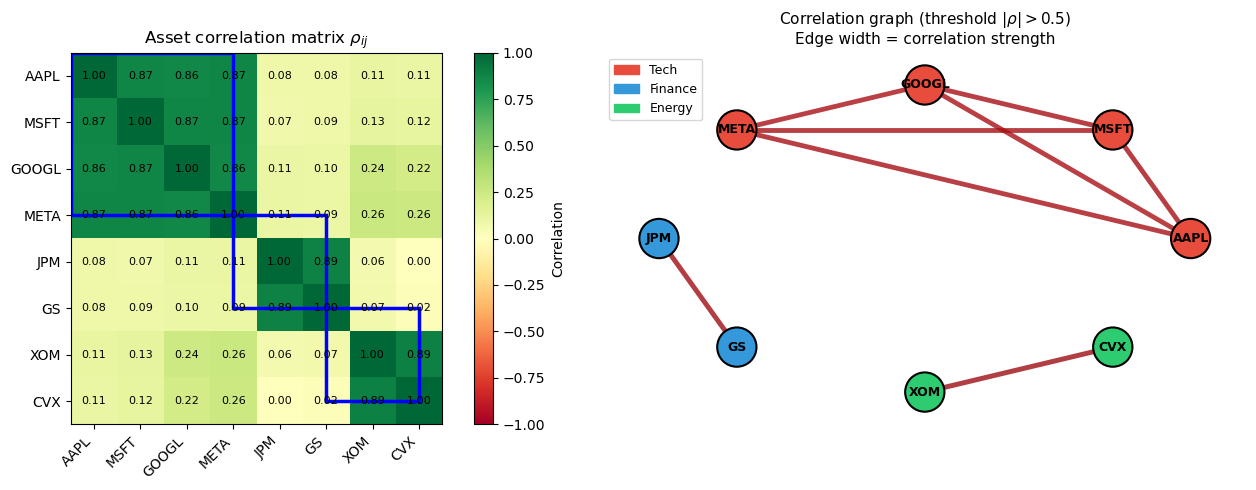

Assets: 8, Edges (|rho|>0.5): 8
Max intra-sector corr: Tech=0.872, Finance=0.886, Energy=0.893


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rng = np.random.default_rng(42)
T = 500   # trading days
n_assets = 8
asset_names = ['AAPL','MSFT','GOOGL','META','JPM','GS','XOM','CVX']
sectors     = ['Tech','Tech','Tech','Tech','Finance','Finance','Energy','Energy']

# ── Synthetic returns with sector structure ───────────────────────
# Each sector has a common factor + idiosyncratic noise
tech_factor    = rng.normal(0, 1, T)
finance_factor = rng.normal(0, 1, T)
energy_factor  = rng.normal(0, 1, T)
market_factor  = rng.normal(0, 0.3, T)  # small common factor

loadings = {
    'AAPL':  (0.8, 0.0, 0.0), 'MSFT':  (0.8, 0.0, 0.0),
    'GOOGL': (0.7, 0.0, 0.1), 'META':  (0.7, 0.0, 0.1),
    'JPM':   (0.0, 0.8, 0.0), 'GS':    (0.0, 0.8, 0.0),
    'XOM':   (0.0, 0.0, 0.8), 'CVX':   (0.0, 0.0, 0.8),
}

returns = np.zeros((n_assets, T))
factors = np.array([tech_factor, finance_factor, energy_factor])
for k, name in enumerate(asset_names):
    load = np.array(loadings[name])
    returns[k] = load @ factors + market_factor + 0.3*rng.normal(0,1,T)

# ── Correlation matrix ────────────────────────────────────────────
corr = np.corrcoef(returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0], label='Correlation')
axes[0].set_xticks(range(n_assets)); axes[0].set_yticks(range(n_assets))
axes[0].set_xticklabels(asset_names, rotation=45, ha='right')
axes[0].set_yticklabels(asset_names)
for i in range(n_assets):
    for j in range(n_assets):
        axes[0].text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='black')
axes[0].set_title('Asset correlation matrix $\\rho_{ij}$', fontsize=12)

# Sector boxes
for (r0,r1,label) in [(0,3.5,'Tech'),(3.5,5.5,'Finance'),(5.5,7.5,'Energy')]:
    axes[0].add_patch(plt.Rectangle((r0-0.5,r0-0.5),r1-r0,r1-r0,
                     fill=False, edgecolor='blue', lw=2.5))

# Graph: threshold at |rho| > 0.5
tau = 0.5
G_port = nx.Graph()
G_port.add_nodes_from(range(n_assets))
for i in range(n_assets):
    for j in range(i+1, n_assets):
        if abs(corr[i,j]) > tau:
            G_port.add_edge(i, j, weight=abs(corr[i,j]))

pos = nx.circular_layout(G_port)
sector_colors = {'Tech':'#E74C3C','Finance':'#3498DB','Energy':'#2ECC71'}
node_colors   = [sector_colors[sectors[k]] for k in range(n_assets)]
edge_weights  = [G_port[u][v]['weight'] for u,v in G_port.edges()]

nx.draw_networkx_nodes(G_port, pos, ax=axes[1], node_color=node_colors,
                       node_size=800, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_port, pos, ax=axes[1],
                        labels={k:asset_names[k] for k in range(n_assets)},
                        font_size=9, font_weight='bold')
nx.draw_networkx_edges(G_port, pos, ax=axes[1],
                       width=[w*4 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.Reds,
                       alpha=0.8, edge_vmin=0, edge_vmax=1)
axes[1].set_title(f'Correlation graph (threshold $|\\rho|>{tau}$)\n'
                  'Edge width = correlation strength', fontsize=11)
axes[1].axis('off')

from matplotlib.patches import Patch
legend = [Patch(color=c, label=s) for s,c in sector_colors.items()]
axes[1].legend(handles=legend, loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

print(f'Assets: {n_assets}, Edges (|rho|>{tau}): {G_port.number_of_edges()}')
print(f'Max intra-sector corr: '
      f'Tech={max(corr[i,j] for i in range(4) for j in range(i+1,4)):.3f}, '
      f'Finance={corr[4,5]:.3f}, Energy={corr[6,7]:.3f}')

### 2.3 MaxCut Solution = Diversification

The MaxCut solution partitions assets so that highly-correlated pairs are separated. For our sector-structured data, the optimal cut should recover the sector boundaries.

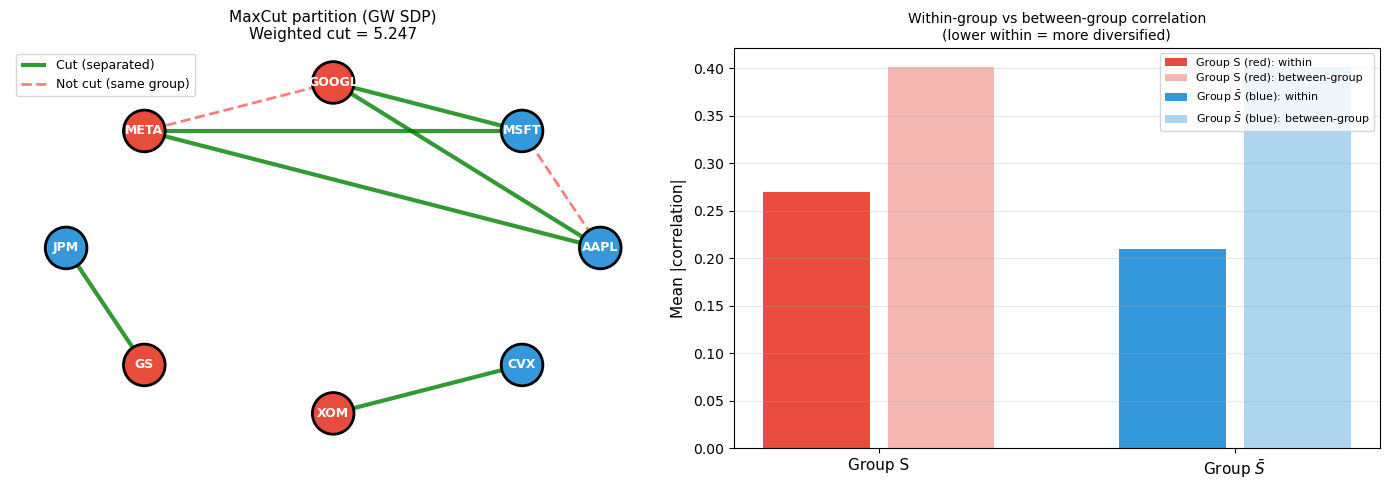

Group S  (red):  ['GOOGL', 'META', 'GS', 'XOM']
Group Sbar(blue): ['AAPL', 'MSFT', 'JPM', 'CVX']
Sectors recovered: Partial


In [2]:
import cvxpy as cp

# ── Weighted MaxCut via GW SDP ────────────────────────────────────
edges_port = list(G_port.edges())
weights_port = [G_port[u][v]['weight'] for u,v in edges_port]

def weighted_cut_val(assignment, edges, weights):
    return sum(w for (i,j),w in zip(edges,weights) if assignment[i]!=assignment[j])

def weighted_maxcut_sdp(n, edges, weights, n_rounds=3000):
    X = cp.Variable((n,n), symmetric=True)
    obj = cp.Maximize(sum(0.5*w*(1-X[i,j]) for (i,j),w in zip(edges,weights)))
    prob = cp.Problem(obj, [X >> 0] + [X[i,i]==1 for i in range(n)])
    prob.solve(solver=cp.SCS, verbose=False)
    eigvals, eigvecs = np.linalg.eigh(X.value)
    eigvals = np.maximum(eigvals, 1e-6)
    V = eigvecs @ np.diag(np.sqrt(eigvals))
    best_cut = -1; best_assign = None
    for _ in range(n_rounds):
        r = rng.standard_normal(n); r /= np.linalg.norm(r)
        assign = (V @ r >= 0).astype(int)
        cv = weighted_cut_val(assign, edges, weights)
        if cv > best_cut:
            best_cut = cv; best_assign = assign.copy()
    return best_assign, best_cut

assign_port, cut_port = weighted_maxcut_sdp(n_assets, edges_port, weights_port)

# ── Visualise the partition ───────────────────────────────────────
group0 = [i for i in range(n_assets) if assign_port[i]==0]
group1 = [i for i in range(n_assets) if assign_port[i]==1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph with partition
node_colors_cut = ['#E74C3C' if assign_port[k]==0 else '#3498DB' for k in range(n_assets)]
cut_edges    = [(i,j) for i,j in edges_port if assign_port[i]!=assign_port[j]]
noncut_edges = [(i,j) for i,j in edges_port if assign_port[i]==assign_port[j]]

nx.draw_networkx_nodes(G_port, pos, ax=axes[0], node_color=node_colors_cut,
                       node_size=900, edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G_port, pos, ax=axes[0],
                        labels={k:asset_names[k] for k in range(n_assets)},
                        font_size=9, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G_port, pos, ax=axes[0], edgelist=cut_edges,
                       edge_color='green', width=3.0, alpha=0.8,
                       style='solid', label='Cut (separated)')
nx.draw_networkx_edges(G_port, pos, ax=axes[0], edgelist=noncut_edges,
                       edge_color='red', width=2.0, alpha=0.5,
                       style='dashed', label='Not cut (same group)')
axes[0].set_title(f'MaxCut partition (GW SDP)\n'
                  f'Weighted cut = {cut_port:.3f}', fontsize=11)
axes[0].axis('off')
axes[0].legend(loc='upper left', fontsize=9)

# Within-group correlation heatmaps
ax2 = axes[1]
for group, color, label, xpos in [
    (group0, '#E74C3C', 'Group S (red)', 0),
    (group1, '#3498DB', r'Group $\bar{S}$ (blue)', 1)
]:
    within_corrs = [corr[i,j] for i in group for j in group if i<j]
    between_corrs= [corr[i,j] for i in group for j in (
        group1 if group==group0 else group0)]
    ax2.bar(xpos*2, np.mean(np.abs(within_corrs)) if within_corrs else 0,
            color=color, width=0.6, label=f'{label}: within')
    ax2.bar(xpos*2+0.7, np.mean(np.abs(between_corrs)),
            color=color, alpha=0.4, width=0.6, label=f'{label}: between-group')

ax2.set_xticks([0.35, 2.35])
ax2.set_xticklabels(['Group S', r'Group $\bar{S}$'], fontsize=11)
ax2.set_ylabel('Mean |correlation|', fontsize=11)
ax2.set_title('Within-group vs between-group correlation\n'
              '(lower within = more diversified)', fontsize=10)
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Group S  (red):  {[asset_names[i] for i in group0]}')
print(f'Group Sbar(blue): {[asset_names[i] for i in group1]}')
print(f'Sectors recovered: ', end='')
print('Yes' if set(group0)=={0,1,2,3} or set(group0)=={4,5,6,7} else 'Partial')

---
## 3. Job Scheduling

### 3.1 The Problem

We have $n$ jobs to schedule into **two time slots** (A and B). Some pairs of jobs **conflict** — they require the same resource and cannot run simultaneously. Goal: assign jobs to slots to minimise the number of conflicts within each slot.

**Formally.** Let $c_{ij}\geq 0$ be the conflict penalty if jobs $i$ and $j$ run in the same slot. The total conflict cost is:

$$\text{Conflict}(z) = \sum_{(i,j)\in E} c_{ij}\cdot\mathbf{1}[z_i=z_j]$$

where $z_i\in\{0,1\}$ is the slot assignment.

### 3.2 Reduction to MaxCut

Note that $\mathbf{1}[z_i=z_j] = 1 - \mathbf{1}[z_i\neq z_j]$, so:

$$\text{Conflict}(z) = \sum_{(i,j)\in E}c_{ij} - \sum_{(i,j)\in E}c_{ij}\cdot\mathbf{1}[z_i\neq z_j] = \mathrm{const} - C_w(z)$$

where $C_w(z)$ is the weighted cut value with weights $w_{ij}=c_{ij}$.

$$\boxed{\min\,\text{Conflict}(z) \iff \max\,C_w(z)}$$

**Minimising conflicts = Maximising the weighted cut on the conflict graph.**

**Graph.** Vertex $i$ = job $i$. Edge $(i,j)$ with weight $c_{ij}$ if jobs conflict. MaxCut separates conflicting jobs into different slots.

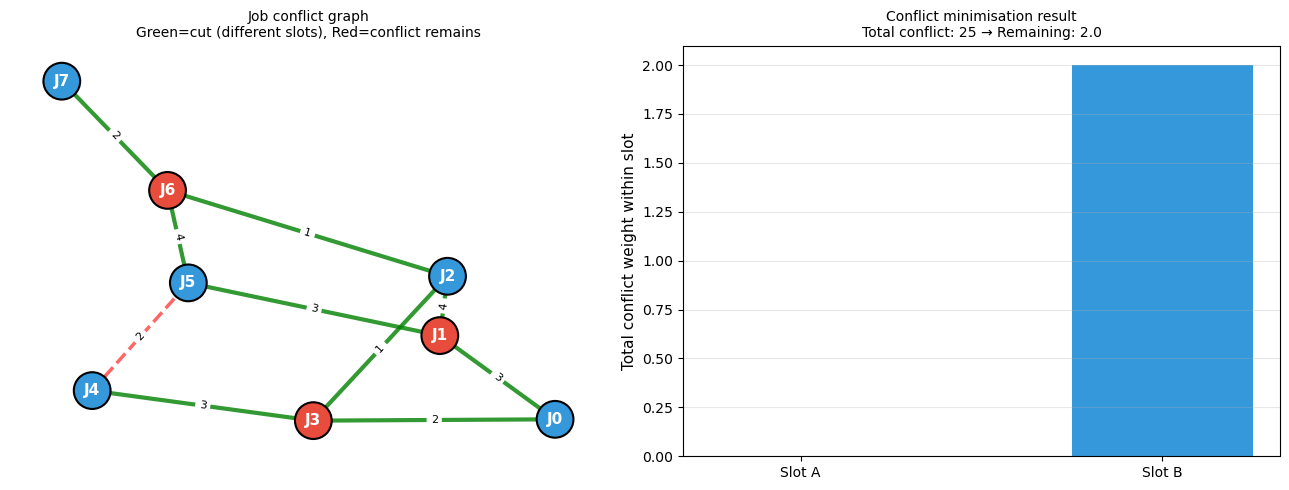

Slot A: ['J1', 'J3', 'J6']
Slot B: ['J0', 'J2', 'J4', 'J5', 'J7']
Total conflict weight: 25
Remaining after MaxCut: 2.0  (8.0%)


In [3]:
# Job scheduling: synthetic example
n_jobs = 8
job_names = [f'J{k}' for k in range(n_jobs)]

# Conflict graph: some job pairs share resources
conflicts = [(0,1,3),(0,3,2),(1,2,4),(2,3,1),(3,4,3),(4,5,2),
             (5,6,4),(6,7,2),(1,5,3),(2,6,1)]
# (i, j, conflict_weight)

G_sched = nx.Graph()
G_sched.add_nodes_from(range(n_jobs))
for i,j,w in conflicts:
    G_sched.add_edge(i,j,weight=w)

# GW to find good assignment
edges_s = list(G_sched.edges())
wts_s   = [G_sched[u][v]['weight'] for u,v in edges_s]
assign_s, cut_s = weighted_maxcut_sdp(n_jobs, edges_s, wts_s)

total_conflict = sum(w for i,j,w in conflicts)
remaining = total_conflict - cut_s

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pos_s = nx.spring_layout(G_sched, seed=7)
node_cols_s = ['#E74C3C' if assign_s[k]==0 else '#3498DB' for k in range(n_jobs)]
cut_e_s = [(i,j) for i,j in edges_s if assign_s[i]!=assign_s[j]]
same_e_s= [(i,j) for i,j in edges_s if assign_s[i]==assign_s[j]]
edge_w_s= [G_sched[u][v]['weight'] for u,v in edges_s]

nx.draw_networkx_nodes(G_sched, pos_s, ax=axes[0], node_color=node_cols_s,
                       node_size=700, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G_sched, pos_s, ax=axes[0],
                        labels={k:job_names[k] for k in range(n_jobs)},
                        font_size=11, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G_sched, pos_s, ax=axes[0], edgelist=cut_e_s,
                       edge_color='green', width=3, alpha=0.8)
nx.draw_networkx_edges(G_sched, pos_s, ax=axes[0], edgelist=same_e_s,
                       edge_color='red', width=2.5, alpha=0.6, style='dashed')
edge_labels_s = {(i,j):G_sched[i][j]['weight'] for i,j in edges_s}
nx.draw_networkx_edge_labels(G_sched, pos_s, ax=axes[0], edge_labels=edge_labels_s, font_size=8)
axes[0].set_title('Job conflict graph\nGreen=cut (different slots), Red=conflict remains', fontsize=10)
axes[0].axis('off')

# Bar: slot A vs slot B
slotA = [job_names[k] for k in range(n_jobs) if assign_s[k]==0]
slotB = [job_names[k] for k in range(n_jobs) if assign_s[k]==1]
axes[1].bar(['Slot A','Slot B'],
           [sum(w for i,j,w in conflicts if assign_s[i]==0 and assign_s[j]==0),
            sum(w for i,j,w in conflicts if assign_s[i]==1 and assign_s[j]==1)],
           color=['#E74C3C','#3498DB'], width=0.5)
axes[1].set_ylabel('Total conflict weight within slot', fontsize=11)
axes[1].set_title(f'Conflict minimisation result\n'
                  f'Total conflict: {total_conflict} → Remaining: {remaining:.1f}', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Slot A: {slotA}')
print(f'Slot B: {slotB}')
print(f'Total conflict weight: {total_conflict}')
print(f'Remaining after MaxCut: {remaining:.1f}  ({remaining/total_conflict*100:.1f}%)')

---
## 4. Facility Location

### 4.1 The Problem

We have $n$ candidate sites for facilities (warehouses, antennas, charging stations). We must choose which sites to **open** (assign to set $S$) vs **not open** (assign to $\bar S$). Sites that are geographically close compete: opening both wastes resources. Goal: choose sites to maximise total coverage while minimising overlap.

### 4.2 Reduction to MaxCut

Define the **overlap penalty** between sites $i$ and $j$ as $o_{ij}\geq 0$ (proportional to the fraction of customers served by both if both are open).

A binary assignment $z_i=1$ if site $i$ is opened. The overlap cost for opening both $i$ and $j$ is $o_{ij}\cdot z_iz_j$. Maximising coverage minus overlap becomes:

$$\max\sum_i v_i z_i - \sum_{(i,j)\in E}o_{ij}z_iz_j$$

The second term $z_iz_j = \frac{1-(-1)^{z_i+z_j}}{2}+\frac{1}{2}$. Rearranging, the penalty for sites on the **same side** ($z_i=z_j$) is avoided by cutting the edge:

$$-\sum_{(i,j)\in E}o_{ij}z_iz_j\;\xrightarrow{\text{QUBO}}\; \text{MaxCut on overlap graph}$$

(plus a diagonal linear term handled by adding ancilla edges to a reference vertex).

**Intuition.** Sites on the same side ($z_i=z_j$) compete. Sites on opposite sides ($z_i\neq z_j$) complement. MaxCut places competing sites on opposite sides — one opens, the other doesn't — maximising geographic spread.

---
## 5. Network Design and Graph Partitioning

### 5.1 Parallel Computing: Load Balancing

In parallel computing, a workload graph has:
- **Vertices** = computational tasks
- **Edges** = communication requirements between tasks
- **Edge weight** $w_{ij}$ = amount of data exchanged

Assign tasks to two processors. Tasks on the **same processor** communicate through fast local memory (cheap). Tasks on **different processors** communicate through a network bus (expensive).

$$\text{Communication cost} = \sum_{(i,j)\in E}w_{ij}\cdot\mathbf{1}[z_i\neq z_j]$$

$$\boxed{\min\,\text{Communication cost} = -\max\,C_w(z) + \mathrm{const}}$$

Wait — here we want to **minimise** the cut (keep communicating tasks together), not maximise it. This is the **minimum bisection** problem, which is also NP-hard.

> **Note:** Minimum bisection is the complement of MaxCut: the optimal MaxCut on the complement graph $\bar G$ (with edges $\bar E = \binom{V}{2}\setminus E$) gives a minimum bisection of $G$. So MaxCut algorithms (including QAOA) apply to both problems.

### 5.2 Telecom Network Design

**Problem.** A telecom company wants to partition $n$ users into two network zones. Within each zone, traffic is handled locally. Between zones, traffic crosses an expensive backbone link.

The backbone cost is proportional to the **traffic between zones** = the cut value. Minimising backbone cost = **MinCut** = complement of MaxCut.

**Graph.** Vertex $i$ = user. Edge weight $w_{ij}$ = traffic between $i$ and $j$. MinCut partitions users to minimise inter-zone traffic.

---
## 6. The QUBO Unification

All the problems above are instances of **QUBO** (Quadratic Unconstrained Binary Optimisation):

$$\min_{z\in\{0,1\}^n}\; z^T Q z = \min_{z}\;\sum_{i,j}Q_{ij}z_iz_j$$

where $Q\in\mathbb{R}^{n\times n}$ encodes the problem structure.

**MaxCut is a special case.** With $Q_{ij}=-w_{ij}$ for $(i,j)\in E$ and $Q_{ii}=\sum_j w_{ij}$ (degree matrix):

$$z^TQz = \sum_i Q_{ii}z_i^2 + \sum_{i\neq j}Q_{ij}z_iz_j = \sum_{(i,j)\in E}w_{ij}(z_i^2+z_j^2-2z_iz_j) = \sum_{(i,j)\in E}w_{ij}(z_i-z_j)^2$$

Since $z_i\in\{0,1\}$: $(z_i-z_j)^2=\mathbf{1}[z_i\neq z_j]$. So:

$$\min z^TQz = \min C_w(z) \quad\Leftrightarrow\quad \max(-C_w(z))$$

Equivalently: $\max C_w(z) = $ MaxCut.

**Why this matters for quantum computing.** QUBO maps directly to an Ising Hamiltonian:

$$H_{\mathrm{QUBO}} = \sum_{i<j}J_{ij}Z_iZ_j + \sum_i h_i Z_i$$

via $z_i = (1-Z_i)/2$. Finding the ground state of $H_{\mathrm{QUBO}}$ solves any QUBO — and therefore any of the applications above. **QAOA provides a natural variational framework for QUBO problems.**

| Problem | $Q$ matrix | Quantum $H_C$ |
|---------|-----------|----------------|
| MaxCut | $Q_{ij}=-w_{ij}$, $Q_{ii}=\deg$ | $\sum_{ij}\frac{w_{ij}(I-Z_iZ_j)}{2}$ |
| Job scheduling | $Q_{ij}=c_{ij}$ (conflict) | $\sum_{ij}\frac{c_{ij}(I+Z_iZ_j)}{2}$ |
| Facility location | $Q_{ij}=-o_{ij}$, $Q_{ii}=v_i$ | mixed diagonal + $ZZ$ terms |
| Min bisection | $Q_{ij}=+w_{ij}$ | $\sum_{ij}\frac{w_{ij}(I+Z_iZ_j)}{2}$ |

The QAOA circuit structure is the same for all — only the edge weights in $U_C$ change.

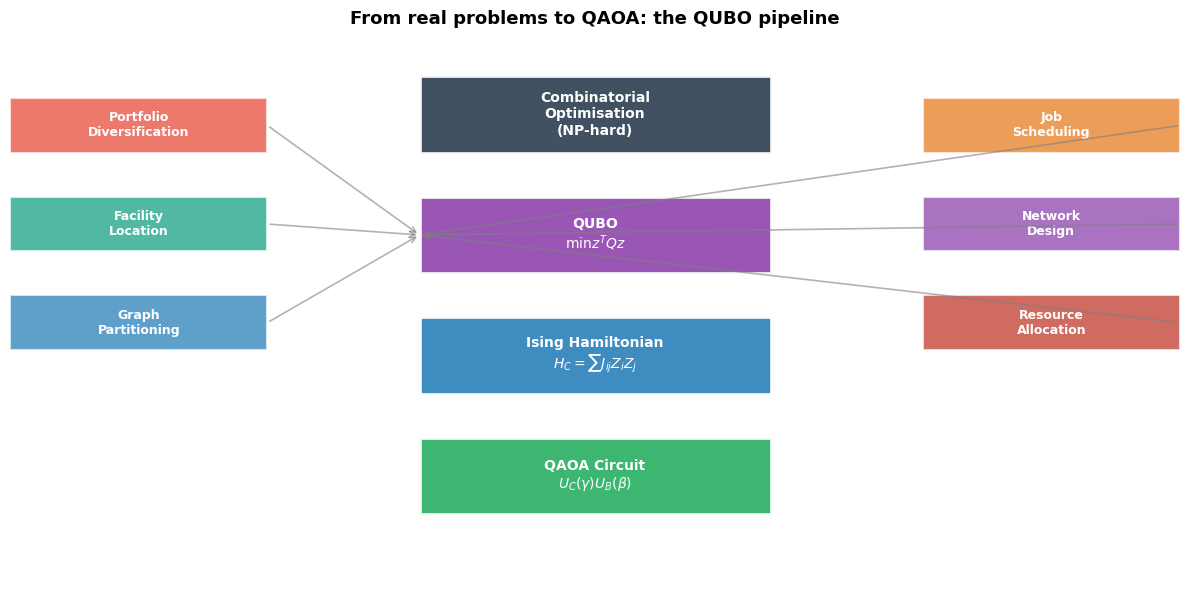

In [4]:
# ── Summary visualisation: problem taxonomy ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Draw hierarchy
boxes = [
    # (x, y, w, h, text, color)
    (0.35, 0.78, 0.30, 0.14, 'Combinatorial\nOptimisation\n(NP-hard)', '#2C3E50'),
    (0.35, 0.56, 0.30, 0.14, 'QUBO\n$\\min z^T Q z$', '#8E44AD'),
    (0.35, 0.34, 0.30, 0.14, 'Ising Hamiltonian\n$H_C = \\sum J_{ij}Z_iZ_j$', '#2980B9'),
    (0.35, 0.12, 0.30, 0.14, 'QAOA Circuit\n$U_C(\\gamma)U_B(\\beta)$', '#27AE60'),
]
applications = [
    (0.00, 0.78, 0.22, 0.10, 'Portfolio\nDiversification', '#E74C3C'),
    (0.78, 0.78, 0.22, 0.10, 'Job\nScheduling', '#E67E22'),
    (0.00, 0.60, 0.22, 0.10, 'Facility\nLocation', '#16A085'),
    (0.78, 0.60, 0.22, 0.10, 'Network\nDesign', '#8E44AD'),
    (0.00, 0.42, 0.22, 0.10, 'Graph\nPartitioning', '#2980B9'),
    (0.78, 0.42, 0.22, 0.10, 'Resource\nAllocation', '#C0392B'),
]

for x,y,w,h,text,color in boxes:
    rect = plt.Rectangle((x,y), w, h, facecolor=color, edgecolor='white',
                         lw=2, transform=ax.transAxes, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', transform=ax.transAxes)

for x,y,w,h,text,color in applications:
    rect = plt.Rectangle((x,y), w, h, facecolor=color, edgecolor='white',
                         lw=1.5, transform=ax.transAxes, alpha=0.75)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', transform=ax.transAxes)

# Arrows (main chain)
for y_start, y_end in [(0.78, 0.70), (0.56, 0.48), (0.34, 0.26)]:
    ax.annotate('', xy=(0.50, y_end), xytext=(0.50, y_start),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='white', lw=2.5))

# Arrows from applications to QUBO box
for x,y,w,h,_,_ in applications:
    ax.annotate('', xy=(0.35, 0.63), xytext=(x+w, y+h/2),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2, alpha=0.6))

ax.set_title('From real problems to QAOA: the QUBO pipeline', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Key Takeaways

1. **MaxCut is a canonical QUBO instance.** Many practical binary optimisation problems — portfolio diversification, job scheduling, facility location, network design — can be reformulated as weighted MaxCut or related QUBO problems on appropriate graphs.

2. **The unifying structure is QUBO.** Every binary quadratic problem maps to an Ising Hamiltonian, and QAOA approximates its ground state. The reduction is exact for the problems shown; more complex constraints require additional penalty terms.

3. **Only the weights change.** The QAOA circuit structure is the same across applications — correlation matrix, conflict penalties, overlap costs all enter as edge weights in $U_C(\gamma)$.

4. **The classical benchmark is GW.** Goemans–Williamson (ratio $\geq 0.8786$) is the polynomial-time classical state of the art. Whether QAOA at polynomial depth can exceed this bound on any practical instance remains an open research question.

---
## References

- Karp, R. *Reducibility among combinatorial problems.* 1972.
- Glover et al. *Quantum Bridge Analytics I: QUBO formulations.* 4OR, 2019.
- Lucas, A. *Ising formulations of many NP problems.* *Front. Phys.* 2, 2014.
- Farhi, Goldstone, Gutmann. arXiv:1411.4028 (2014).
- Goemans, Williamson. *JACM* 42(6), 1995.